# 基于增量 SVD 的椭圆 PDE 降阶求解（Incremental SVD ROM）

这份 notebook 对一维参数化椭圆方程做有限元离散，并基于 **增量 SVD** 构造降阶基，随后在测试集上自动选择最合适的快照矩阵 $U_k$。

## 研究目标

给定：

- 训练参数集：500 个 $a$
- 测试参数集：20 个 $a$
- 最小快照数：从 $k=10$ 开始评估

对每一个

$$
U_k = [u(a_1), u(a_2), \dots, u(a_k)]
$$

都采用 **增量 SVD** 来更新分解，而不是像 batch SVD 那样每次都对整个矩阵重新做一次 SVD。

然后在 20 个测试参数上评估 ROM 精度，并记录：

- 当前快照数 $k$
- 当前降阶维数 $r$
- 测试集平均相对误差
- 测试集最大相对误差
- 增量 SVD 累积离线时间
- 当前评估时间
- 程序总时间

最终选出一个最优的 $U_k$，尽量避免：

- $k$ 太小带来的 **欠拟合**
- $k$ 太大带来的 **过拟合** 或不必要复杂度上升

---

## PDE 模型

这里采用的一维参数化椭圆方程是：

$$
-\frac{d}{dx}\left(k(x;a)\frac{du}{dx}\right)=f(x), \quad x\in(0,1),
$$

并配上齐次 Dirichlet 边界条件：

$$
u(0)=u(1)=0.
$$

系数函数与右端项取为：

$$
k(x;a)=1+a x, \qquad f(x)=1.
$$

只要 $a>-1$，就有 $k(x;a)>0$，因此问题保持椭圆性。

---

## 有限元离散

做线性有限元离散后，得到全阶系统：

$$
A(a) u_h(a)=b.
$$

在降阶阶段，若基矩阵记为 $V\in \mathbb{R}^{N\times r}$，则 Galerkin ROM 写作：

$$
V^T A(a) V \, c(a) = V^T b,
$$

再恢复近似解：

$$
u_r(a)=V c(a).
$$

---

## 增量 SVD 的核心思想

与 batch SVD 不同，这里不是对每个 $U_k$ 从头做一次分解，而是随着新快照 $u(a_k)$ 到来，逐步更新当前分解。

当前快照矩阵记为：

$$
U_k \approx Q \Sigma R^T,
$$

其中：

$$
Q^T M Q = I, \qquad R^T R = I.
$$

这里 $M$ 是有限元质量矩阵，因此采用的是 **加权内积**，也就是：

$$
\langle x, y \rangle_M = x^T M y.
$$

每次加入一个新快照后：

1. 先把新向量投影到当前子空间
2. 计算残差大小
3. 若残差很小，则视为“近线性相关”，暂时缓存
4. 若残差显著，则做 rank-increasing update
5. 对每个 $k\ge 10$，在测试集上评估一次当前 ROM 精度

---

## 选阶准则

对当前奇异值 $\sigma_1,\sigma_2,\dots$，采用累计能量阈值来选取降阶维数 $r$：

$$
\frac{\sum_{i=1}^{r} \sigma_i^2}{\sum_{i=1}^{m} \sigma_i^2} \ge \eta,
$$

其中 $\eta$ 是能量阈值，比如 0.999。

---

## 误差定义

对测试参数上的全阶解 $u_h$ 与降阶解 $u_r$，用质量矩阵诱导范数定义相对误差：

$$
\mathrm{err}(a)=
\frac{\|u_h(a)-u_r(a)\|_M}{\|u_h(a)\|_M},
$$

其中

$$
\|v\|_M = \sqrt{v^T M v}.
$$

---

## 说明

- 本 notebook 的主逻辑已经封装在 `incremental_pde_rom.py` 中。
- notebook 负责：
  - 导入模块
  - 调用实验
  - 展示结果
  - 绘图
  - 输出最优模型摘要
- 你后续若要替换成你自己的 PDE，只需要修改 `.py` 文件里的 FEM 装配与全阶求解部分即可。


In [1]:
import sys
from pathlib import Path

# 让 notebook 能够导入 /mnt/data 中的模块
sys.path.append("/mnt/data")

from incremental_pde_rom import (
    run_incremental_rom_selection,
    print_top_candidates,
    records_to_arrays,
)


# 运行主实验

下面这个单元会执行完整实验流程：

1. 生成 500 个训练参数
2. 生成 20 个测试参数
3. 计算训练集与测试集上的全阶解
4. 对每个 $k\ge 10$ 做增量 SVD 与测试集评估
5. 自动选出最优的 $U_k$

你可以先直接运行默认参数。

In [2]:
result = run_incremental_rom_selection(
    n_elements=200,   # FEM 网格单元数
    n_train=500,      # 训练参数个数
    n_test=20,        # 测试参数个数
    min_k=10,         # 从 k=10 开始评估
    a_min=0.0,        # 参数区间左端
    a_max=2.0,        # 参数区间右端
    seed=42,          # 随机种子（测试集抽样会用到）
    svd_tol=1e-10,    # 增量SVD容差
    energy_tol=0.999, # 能量保留阈值
    verbose=True,
)


[k= 10] r=  1 | mean err=9.371e-02 | max err=1.440e-01 | offline=0.001s | eval=0.001s
[k= 25] r=  1 | mean err=8.970e-02 | max err=1.396e-01 | offline=0.002s | eval=0.000s
[k= 50] r=  1 | mean err=8.353e-02 | max err=1.329e-01 | offline=0.002s | eval=0.000s
[k= 75] r=  1 | mean err=7.805e-02 | max err=1.268e-01 | offline=0.004s | eval=0.000s
[k=100] r=  1 | mean err=7.340e-02 | max err=1.213e-01 | offline=0.004s | eval=0.000s
[k=125] r=  1 | mean err=6.946e-02 | max err=1.162e-01 | offline=0.005s | eval=0.000s
[k=150] r=  1 | mean err=6.597e-02 | max err=1.115e-01 | offline=0.006s | eval=0.000s
[k=175] r=  1 | mean err=6.304e-02 | max err=1.071e-01 | offline=0.007s | eval=0.000s
[k=200] r=  1 | mean err=6.032e-02 | max err=1.031e-01 | offline=0.008s | eval=0.001s
[k=225] r=  1 | mean err=5.778e-02 | max err=9.929e-02 | offline=0.009s | eval=0.000s
[k=250] r=  1 | mean err=5.541e-02 | max err=9.574e-02 | offline=0.010s | eval=0.000s
[k=275] r=  1 | mean err=5.318e-02 | max err=9.239e-02

# 查看最优结果摘要

In [3]:
best = result["best_summary"]
print(best)


BestModelSummary(best_k=500, best_r=2, best_mean_rel_error=0.0015560325352234497, best_max_rel_error=0.00392609406870363, best_energy_kept=0.9999967659384708, offline_time_cum=0.020765517999905114, eval_time=0.0007360299999845665, total_time=0.02150154799988968)


# 查看误差最小的前 10 个候选 $U_k$

这一步会输出一个简洁的排序表，方便你快速看出：

- 最优的快照数 $k$ 是多少
- 对应的降阶维数 $r$ 是多少
- 平均误差和最大误差分别是多少
- 离线时间的量级如何


In [4]:
print_top_candidates(result["records"], top_n=10)


rank      k      r       mean_err        max_err   offline(s)
   1    500      2   1.556033e-03   3.926094e-03       0.0208
   2    499      2   1.559466e-03   3.944990e-03       0.0208
   3    498      2   1.562921e-03   3.963923e-03       0.0207
   4    497      2   1.566397e-03   3.982895e-03       0.0207
   5    496      2   1.569894e-03   4.001904e-03       0.0205
   6    495      2   1.573411e-03   4.020952e-03       0.0205
   7    494      2   1.576947e-03   4.040039e-03       0.0205
   8    493      2   1.580502e-03   4.059164e-03       0.0205
   9    492      2   1.584077e-03   4.078328e-03       0.0205
  10    491      2   1.587670e-03   4.097530e-03       0.0205


# 将记录整理成数组

后面画图会更方便。

In [5]:
arr = records_to_arrays(result["records"])

k_vals = arr["k"]
rank_vals = arr["rank"]
energy_vals = arr["energy"]
mean_err_vals = arr["mean_rel_error"]
max_err_vals = arr["max_rel_error"]
offline_time_vals = arr["offline_time_cum"]
eval_time_vals = arr["eval_time"]
total_time_vals = arr["total_time"]


# 图 1：测试集平均相对误差随快照数 $k$ 的变化

这张图最关键。它可以帮助你判断：

- 当 $k$ 太小时，误差偏大，说明信息不足
- 当 $k$ 增大后，误差下降
- 某个区间后可能趋于平稳，继续增加快照收益有限

这正对应你想做的“避免欠拟合与过拟合”的思路。

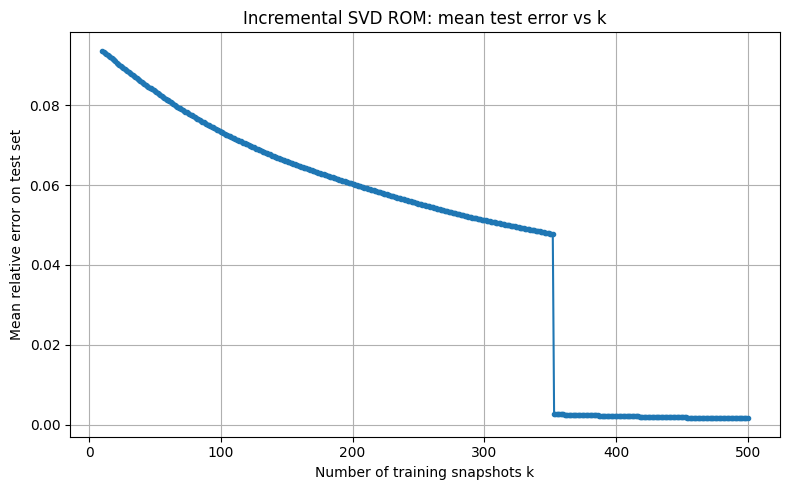

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_vals, mean_err_vals, marker="o", markersize=3)
plt.xlabel("Number of training snapshots k")
plt.ylabel("Mean relative error on test set")
plt.title("Incremental SVD ROM: mean test error vs k")
plt.grid(True)
plt.tight_layout()
plt.show()


# 图 2：测试集最大相对误差随快照数 $k$ 的变化

最大误差可以帮助你看模型在“最难测试点”上的表现。

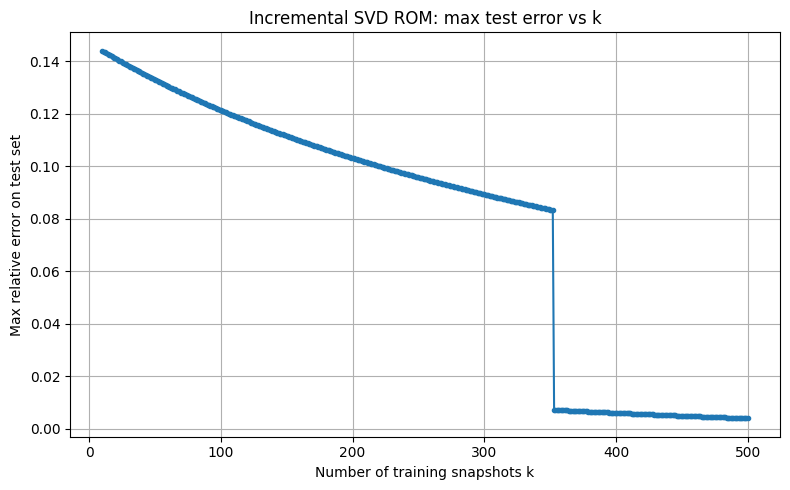

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(k_vals, max_err_vals, marker="o", markersize=3)
plt.xlabel("Number of training snapshots k")
plt.ylabel("Max relative error on test set")
plt.title("Incremental SVD ROM: max test error vs k")
plt.grid(True)
plt.tight_layout()
plt.show()


# 图 3：降阶维数 $r$ 随快照数 $k$ 的变化

由于这里采用的是能量阈值选阶：

$$
\frac{\sum_{i=1}^{r} \sigma_i^2}{\sum_{i=1}^{m} \sigma_i^2} \ge \eta,
$$

所以随着快照数增加，所选的 $r$ 往往也会变化。

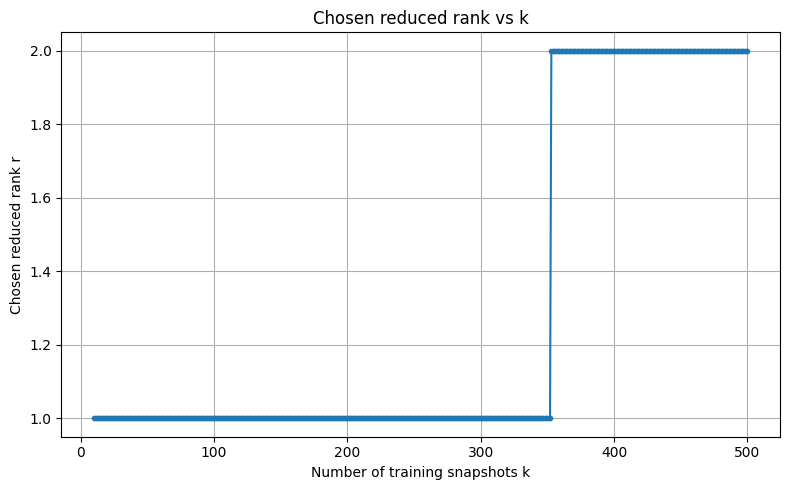

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_vals, rank_vals, marker="o", markersize=3)
plt.xlabel("Number of training snapshots k")
plt.ylabel("Chosen reduced rank r")
plt.title("Chosen reduced rank vs k")
plt.grid(True)
plt.tight_layout()
plt.show()


# 图 4：累计离线时间随快照数 $k$ 的变化

这里记录的是增量 SVD 的累计离线更新耗时。  
如果和 batch SVD 做比较，这张图会特别有意义，因为 batch SVD 往往需要对每个 $U_k$ 重做整次分解。

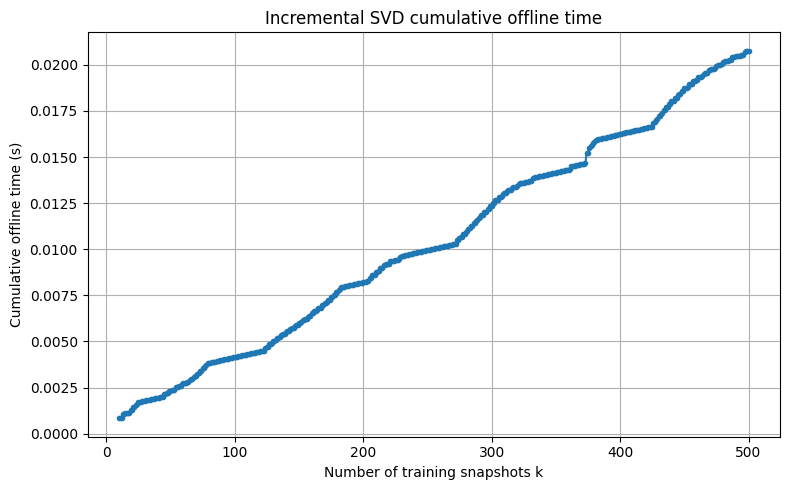

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(k_vals, offline_time_vals, marker="o", markersize=3)
plt.xlabel("Number of training snapshots k")
plt.ylabel("Cumulative offline time (s)")
plt.title("Incremental SVD cumulative offline time")
plt.grid(True)
plt.tight_layout()
plt.show()


# 图 5：单次评估时间随快照数 $k$ 的变化

这里的评估时间包括：

- 对当前增量 SVD 状态做 finalize
- 在 20 个测试参数上做 ROM 求解
- 计算误差

这能反映“模型选择阶段”的成本。

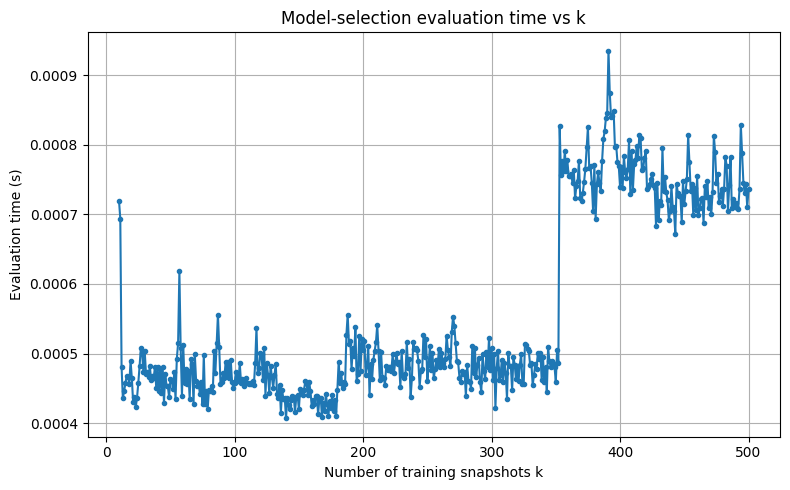

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(k_vals, eval_time_vals, marker="o", markersize=3)
plt.xlabel("Number of training snapshots k")
plt.ylabel("Evaluation time (s)")
plt.title("Model-selection evaluation time vs k")
plt.grid(True)
plt.tight_layout()
plt.show()


# 输出最优模型的详细解释

这一步把最优结果组织成更容易阅读的形式。

In [11]:
best = result["best_summary"]

print("=" * 80)
print("最优增量 SVD 快照矩阵结果")
print("=" * 80)
print(f"最优快照数 best_k              = {best.best_k}")
print(f"对应降阶维数 best_r            = {best.best_r}")
print(f"测试集平均相对误差             = {best.best_mean_rel_error:.6e}")
print(f"测试集最大相对误差             = {best.best_max_rel_error:.6e}")
print(f"保留能量比例                   = {best.best_energy_kept:.6f}")
print(f"累计离线时间                   = {best.offline_time_cum:.6f} s")
print(f"当前评估时间                   = {best.eval_time:.6f} s")
print(f"当前总时间                     = {best.total_time:.6f} s")
print(f"全阶解预计算时间               = {result['fom_precompute_time']:.6f} s")


最优增量 SVD 快照矩阵结果
最优快照数 best_k              = 500
对应降阶维数 best_r            = 2
测试集平均相对误差             = 1.556033e-03
测试集最大相对误差             = 3.926094e-03
保留能量比例                   = 0.999997
累计离线时间                   = 0.020766 s
当前评估时间                   = 0.000736 s
当前总时间                     = 0.021502 s
全阶解预计算时间               = 2.016249 s


# 可选：查看训练参数和测试参数

这样你可以确认参数采样方式。

In [12]:
a_train = result["a_train"]
a_test = result["a_test"]

print("a_train[:20] =")
print(a_train[:20])

print("\na_test =")
print(a_test)


a_train[:20] =
[0.         0.00400802 0.00801603 0.01202405 0.01603206 0.02004008
 0.0240481  0.02805611 0.03206413 0.03607214 0.04008016 0.04408818
 0.04809619 0.05210421 0.05611222 0.06012024 0.06412826 0.06813627
 0.07214429 0.0761523 ]

a_test =
[1.5479121  0.87775688 1.71719584 1.39473606 0.1883547  1.9512447
 1.5222794  1.57212861 0.25622727 0.90077188 0.74159605 1.85352998
 1.28773024 1.64552323 0.8868284  0.45447744 1.10916957 0.12763451
 1.65526234 1.2633288 ]


# 可选：保存结果数据

如果你后面要写报告、做答辩图，最好把结果保存下来。

In [14]:
import numpy as np

np.savez(
    "/home/leaddis/undergraduate-thesis/final/code/increment_SVD/data/incremental_rom_results.npz",
    k=k_vals,
    rank=rank_vals,
    energy=energy_vals,
    mean_rel_error=mean_err_vals,
    max_rel_error=max_err_vals,
    offline_time_cum=offline_time_vals,
    eval_time=eval_time_vals,
    total_time=total_time_vals,
    a_train=result["a_train"],
    a_test=result["a_test"],
)

print("结果已保存到 data/incremental_rom_results.npz")


结果已保存到 data/incremental_rom_results.npz
